In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from haversine import haversine_vector
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)
import lightgbm as lgb
import shap


GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preprocessing - GRAFT

the first step of the preprocessing is to load the dataset and inspect it

In [2]:
try:
    df
except NameError:
    df = pd.read_csv("./processed_1.csv", sep='|')

def sanity_check(df):
    print(df.head())
    print(df.describe())
    print(df.dtypes)
    return

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410998 entries, 0 to 3410997
Data columns (total 26 columns):
 #   Column      Dtype  
---  ------      -----  
 0   ssn         object 
 1   cc_num      int64  
 2   first       object 
 3   last        object 
 4   gender      object 
 5   street      object 
 6   city        object 
 7   state       object 
 8   zip         int64  
 9   lat         float64
 10  long        float64
 11  city_pop    int64  
 12  job         object 
 13  dob         object 
 14  acct_num    int64  
 15  profile     object 
 16  trans_num   object 
 17  trans_date  object 
 18  trans_time  object 
 19  unix_time   int64  
 20  category    object 
 21  amt         float64
 22  is_fraud    int64  
 23  merchant    object 
 24  merch_lat   float64
 25  merch_long  float64
dtypes: float64(5), int64(6), object(15)
memory usage: 676.6+ MB


In [4]:
df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long
0,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,263f4a79ad17a47197f43799a21569de,2025-06-25,03:35:14,1750815314,grocery_pos,357.41,1,fraud_Hudson-Ratke,40.084503,-75.389254
1,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,e02300c84182f711f2a9f9846f6ced13,2025-06-25,03:25:49,1750814749,shopping_pos,337.84,1,fraud_Pagac LLC,41.722363,-75.736086
2,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,f49e7c7d9a7ca2fbe997a294e5a59cd8,2025-06-25,03:57:10,1750816630,shopping_net,721.87,1,"fraud_Greenholt, O'Hara and Balistreri",40.353946,-76.193893
3,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,99df4ad40231b0de46b6e9bd73a128a9,2025-06-25,02:57:47,1750813067,grocery_pos,914.11,1,fraud_Schamberger-O'Keefe,39.910533,-75.510399
4,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,52b0bc313b62e84153697efdf8bb0780,2025-06-25,09:24:34,1750836274,misc_pos,550.26,1,"fraud_Cremin, Hamill and Reichel",40.641295,-75.923638


In [5]:
df.describe()

,cc_num,zip,lat,long,city_pop,acct_num,unix_time,amt,is_fraud,merch_lat,merch_long
count,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06
mean,3.188553e+17,5.181288e+04,3.753286e+01,-9.227034e+01,2.807726e+05,5.012861e+11,1.753076e+09,7.397749e+01,1.111346e-02,3.753258e+01,-9.227073e+01
std,1.154806e+18,2.955658e+04,5.217553e+00,1.630849e+01,5.310730e+05,2.907971e+11,9.056338e+06,1.671417e+02,1.048330e-01,5.249590e+00,1.631872e+01
min,6.040192e+10,1.007000e+03,1.965310e+01,-1.644361e+02,1.450000e+02,4.681899e+08,1.735686e+09,1.000000e+00,0.000000e+00,1.866024e+01,-1.654293e+02
25%,3.684538e+13,2.822700e+04,3.385840e+01,-9.932050e+01,1.780200e+04,2.539607e+11,1.745661e+09,9.220000e+00,0.000000e+00,3.378801e+01,-9.943941e+01
50%,3.502928e+15,4.822100e+04,3.824950e+01,-8.759380e+01,5.985300e+04,5.018392e+11,1.753207e+09,4.510000e+01,0.000000e+00,3.820623e+01,-8.736497e+01
75%,4.514627e+15,7.852100e+04,4.125230e+01,-8.022280e+01,2.326250e+05,7.519589e+11,1.761148e+09,8.307000e+01,0.000000e+00,4.130746e+01,-8.023021e+01
max,4.998442e+18,9.976200e+04,6.483930e+01,-6.784020e+01,2.906700e+06,9.999583e+11,1.767222e+09,2.263405e+04,1.000000e+00,6.583852e+01,-6.684023e+01


### Train/Test split
The dataset is heavily unbalanced w.r.t. the target variable (isFraud - ~1.1% positive).
We need to split without disrupting the distribution.
The test data will be only used for the final SL model evaluation. It will then be used in the RL section to try to learn a better policy.

In [6]:
y = df['is_fraud']
X = df.drop(columns=['is_fraud'])
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y, random_state=GLOBAL_SEED)

## Feature selection and engineering
The dataset is large. After careful consideration, the following design choices were made:
#### legend:
* i = **i**ncluded as-is. 
* n = **n**ot included in the feature vector
* t = **t**ransformed
* l = could be informative, could be added **l**ater in case of underfitting

### Initial feature selection / preprocessing

| feature name   | decision (n / i / t) | notes |
|----------------|----------------------|-------|
| ssn            | n | not informative |
| cc_num         | n | unique per record, not informative |
| first          | n | not informative |
| last           | n | not informative |
| gender         | i | kept raw, LightGBM can work with categorial features without explicit encoding |
| street         | n | not informative |
| city           | n | not informative |
| state          | n | not informative |
| zip            | n | not informative |
| lat       | t | replaced with Haversine distance from lat_merchant / long_merchant |
|long| t | same as "lat"|
| city_pop       | i | kept raw |
| job            | n | weakly informative (only 6 observations per job) |
| dob            | t | transformed to age at transaction time (= 2025 − yob) |
| acct_num       | n | not informative |
| profile        | i | kept raw  |
| trans_num      | n | unique, not informative |
| trans_date     | t | month extracted (t: possible cyclical encoding with sin/cos) |
| trans_time     | t | hour extracted |
| unix_time      | n | redundant with date/time |
| category       | i | kept raw  |
| amt         | i | kept raw  |
| is_fraud        | i | target, kept raw |
| merchant       | l | could be replaced with mean_amount_merchant or excluded in favor of mean_amount_category |
| merch_lat   | t | used only in distance calculation |
| merch_long  | t | used only in distance calculation |


In [7]:
def deterministic_preprocessor(X):
    columns_to_drop = ['ssn','cc_num','first','last','street','city','state','zip','job','acct_num','trans_num','unix_time','merchant']
    X.drop(columns=columns_to_drop, inplace=True) #dropping useless columns

    #date processing
    X = X.rename(columns={'dob':'years', 'trans_date':'trans_month', 'trans_time':'trans_hour'})
    X['years'] = 2025 - pd.to_datetime(X['years']).dt.year
    X['trans_month'] = pd.to_datetime(X['trans_month']).dt.month
    X['trans_hour'] = pd.to_datetime(X['trans_hour'], format='%H:%M:%S').dt.hour


    #categorial feature fix for trees
    X[['gender', 'profile', 'category']] = X[['gender', 'profile', 'category']].astype('category')

    #dist calculation via haversine on lat,long,merch_lat,merch_long and subsequent drop of coordinates columns
    coords_1 = list(zip(X['lat'], X['long']))   #haversine accepts coordinates in (lat,long) format, so zipping is necessary
    coords_2 = list(zip(X['merch_lat'], X['merch_long'])) #same for merchant coordinates
    X['distance_km'] = haversine_vector(coords_1, coords_2)   #add column to dataset
    X.drop(columns=['lat','long','merch_lat','merch_long'], inplace=True) #dropping now-useless, distance columns
    return X


X_train = deterministic_preprocessor(X_train)
X_test =  deterministic_preprocessor(X_test)

sanity_check(X_train)

        gender  city_pop  years profile  trans_month  trans_hour  \
1945560      F      1096     64   rural            4           6   
213928       F    215808     32   urban            1           5   
1039590      F     11630     33   urban            9          14   
1944907      F      1573     52   rural            2           2   
2052988      F     92094     75   urban            9          23   

               category     amt  distance_km  
1945560     grocery_pos   80.42    90.421574  
213928    gas_transport   39.89    86.557921  
1039590  health_fitness    8.55    84.025125  
1944907   gas_transport  235.11    49.138834  
2052988  health_fitness   53.23    75.205141  
           city_pop         years   trans_month    trans_hour           amt  \
count  2.728798e+06  2.728798e+06  2.728798e+06  2.728798e+06  2.728798e+06   
mean   2.809800e+05  4.452411e+01  7.138317e+00  1.286420e+01  7.400958e+01   
std    5.311903e+05  1.748393e+01  3.417784e+00  6.828785e+00  1.687627e

In [8]:
#TODO this cell only serves to open "X_Train" in Data Wrangler
X_train

,gender,city_pop,years,profile,trans_month,trans_hour,category,amt,distance_km
1945560,F,1096,64,rural,4,6,grocery_pos,80.42,90.421574
213928,F,215808,32,urban,1,5,gas_transport,39.89,86.557921
1039590,F,11630,33,urban,9,14,health_fitness,8.55,84.025125
1944907,F,1573,52,rural,2,2,gas_transport,235.11,49.138834
2052988,F,92094,75,urban,9,23,health_fitness,53.23,75.205141
...,...,...,...,...,...,...,...,...,...
1826316,M,2383912,27,urban,7,15,shopping_pos,4.65,83.846409
1683981,M,65336,41,urban,11,17,home,8.47,73.401009
1656558,M,386505,34,urban,1,1,gas_transport,1.02,122.151084
1265939,M,21222,30,urban,8,16,food_dining,11.55,137.773864


# Section II - Supervised Learning
In this section we address the first phase of the project: training a model to output $P(x = \text{fraud})$.
## Gradient Boosted Trees
The technology chosen for this task was Gradient Boosted Trees, in the form of the library LightGBM. This choice was made mainly to take advantage of the natural non-linearity of decision trees splits ("Amount > x AND feature < y THEN fraud>") while keeping a decent interpretability.
The first step is to split again the training set X_train in a sub-training set and a validation test X_val. The validation set will be 5% of the training set (so ~4% of the original dataset). It will be used primarialy to Early Stop the model.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.05, stratify=y_train, random_state=GLOBAL_SEED) #validation set for early stopping and hyperparameter tuning

In [10]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum() #LightGBM prefers this parameter over class_weight when used in binary classification tasks

Let's define the model and its parameters:

In [11]:
#MODEL PARAMETERS
params = {
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "max_depth": -1,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample_for_bin": 200000,
    "objective": "binary",
    "class_weight": None,
    "min_split_gain": 0.0,
    "min_child_weight": 0.001,
    "min_child_samples": 20,
    "subsample": 1.0,
    "subsample_freq": 0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
    "random_state": GLOBAL_SEED,
    "n_jobs": 8,
    "importance_type": "split",
    "is_unbalance": False,
    "scale_pos_weight": scale_pos_weight,
}

early_stopping_rounds = 50 #number of rounds with no improvement after which training will be stopped, default is None (no early stopping)
log_evaluation = 50 #frequency of logging evaluation results, default is 100, setting it to 50 means that evaluation results will be logged every 50 iterations

#model definition and training with early stopping and evaluation logging
model = lgb.LGBMClassifier(**params)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          eval_metric='binary_logloss',
          callbacks=[lgb.early_stopping(early_stopping_rounds),lgb.log_evaluation(log_evaluation)])



[LightGBM] [Info] Number of positive: 28810, number of negative: 2563548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 2592358, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011113 -> initscore=-4.488425
[LightGBM] [Info] Start training from score -4.488425
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.0462707
[100]	valid_0's binary_logloss: 0.0368532
[150]	valid_0's binary_logloss: 0.0308586
[200]	valid_0's binary_logloss: 0.0267429
[250]	valid_0's binary_logloss: 0.0251072
[300]	valid_0's binary_logloss: 0.022482
[350]	valid_0's binary_logloss: 0.0209193
[400]	valid_0's binary_logloss: 0.0189296
[450]	valid_0's binary_logloss: 0.0176948
[50

LGBMClassifier(is_unbalance=False, n_estimators=1000, n_jobs=8,
               objective='binary', random_state=42,
               scale_pos_weight=88.9809538883613)

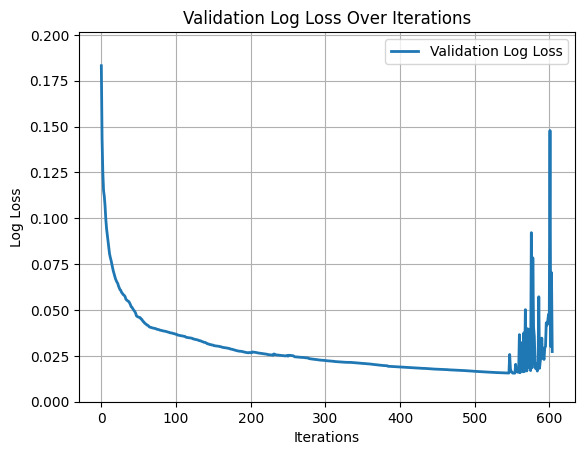

In [12]:
#plot of results
eval_errors = model.evals_result_
plt.plot(eval_errors['valid_0']['binary_logloss'], label='Validation Log Loss', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('Validation Log Loss Over Iterations')
plt.ylim(0, max(eval_errors['valid_0']['binary_logloss']) * 1.1) #set y-axis limit to 10% above the maximum log loss value for better visualization
plt.grid(True)
plt.legend()
plt.show()

# Model evaluation



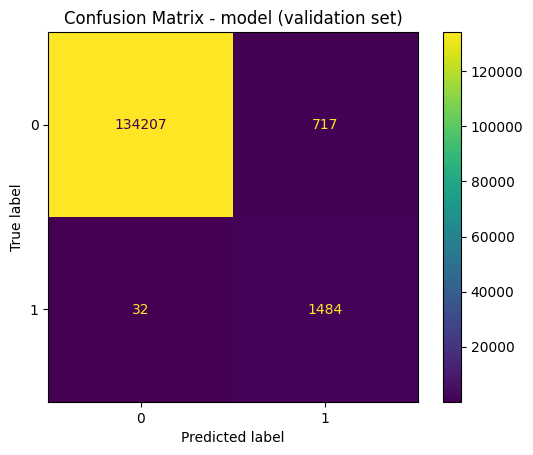

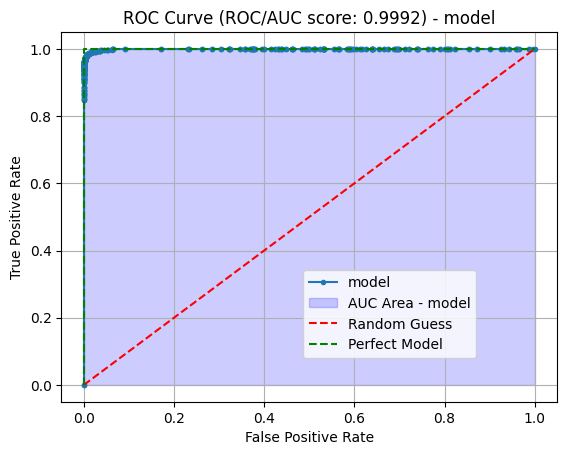

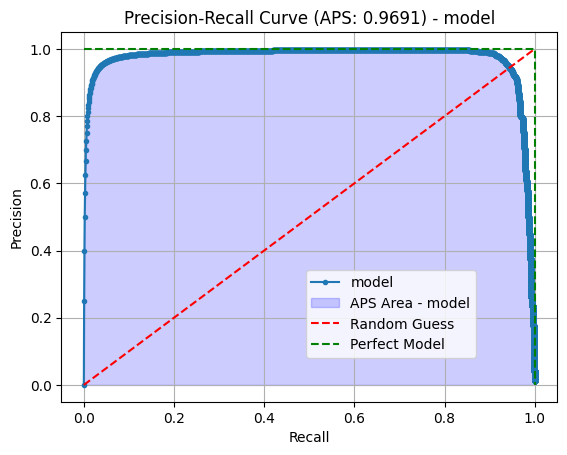

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    134924
           1       0.67      0.98      0.80      1516

    accuracy                           0.99    136440
   macro avg       0.84      0.99      0.90    136440
weighted avg       1.00      0.99      1.00    136440

Average test loss on test set: 0.0156 - model


In [13]:
#Model evaluation on validation set
#Accuracy is useless - we want Precision, Recall, confusion matrix.

y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1] #probability of the positive class

ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title('Confusion Matrix - model (validation set)')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
plt.plot(fpr, tpr, marker='.', label='model')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_val, y_pred_proba):.4f}) - model')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)
plt.plot(recall[:-1], precision[:-1], marker='.', label='model') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_val, y_pred_proba):.4f}) - model')
#put legend in upper right corner, where it doesn't cover the curve
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_val, y_pred))
print(f'Average test loss on test set: {log_loss(y_val, y_pred_proba):.4f} - model')

as we can see, curves are near the optimal value etc.

## Test time!
Let's see how well the model does on the test set:

### Baseline Models
As baseline models I chose:

N0: always predicts 0

N1: always predicts 1

R: predicts randomly

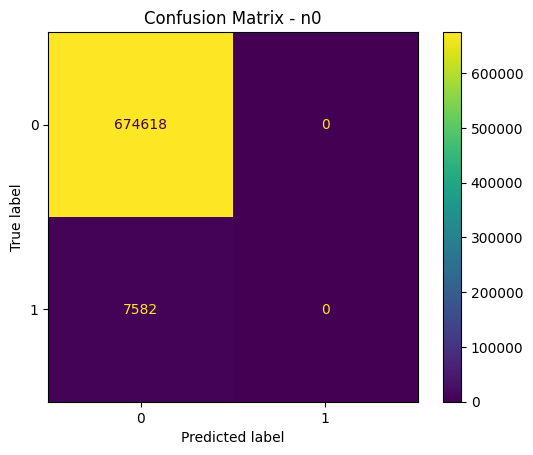

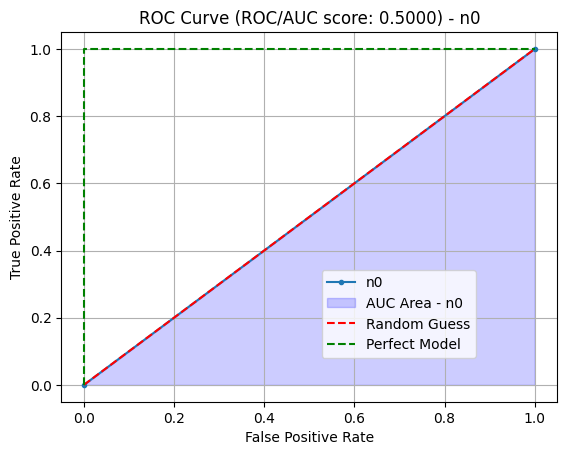

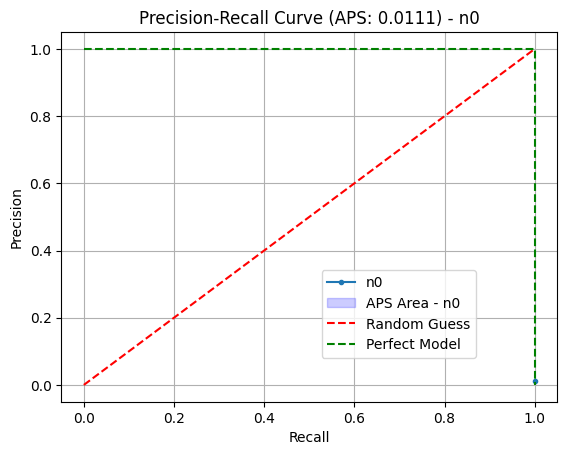

c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99    674618
           1       0.00      0.00      0.00      7582

    accuracy                           0.99    682200
   macro avg       0.49      0.50      0.50    682200
weighted avg       0.98      0.99      0.98    682200

Average test loss on test set: 0.4006 - n0


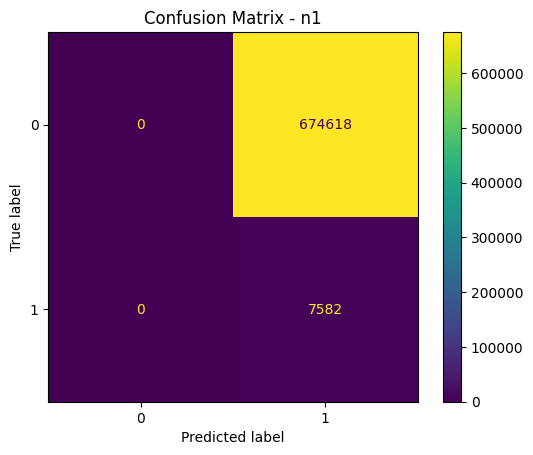

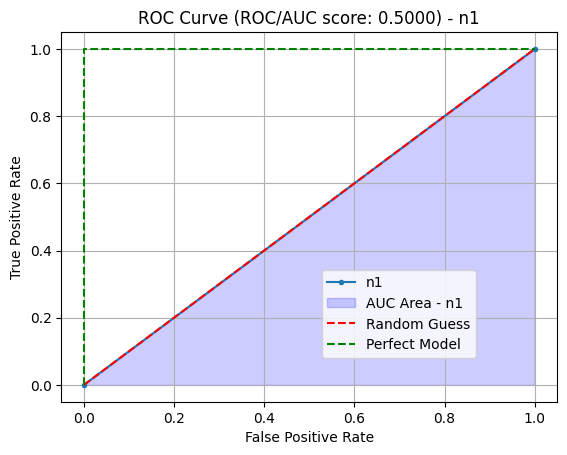

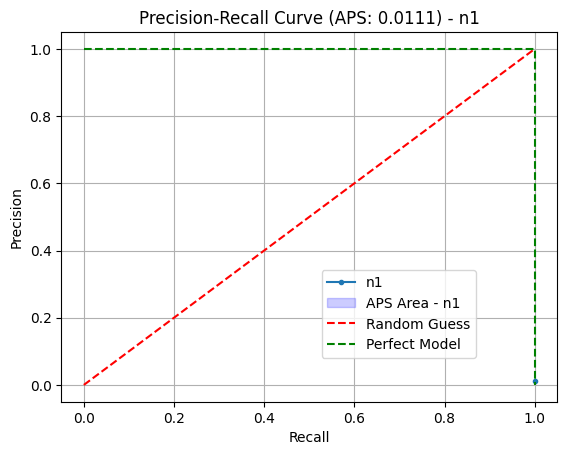

c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00    674618
           1       0.01      1.00      0.02      7582

    accuracy                           0.01    682200
   macro avg       0.01      0.50      0.01    682200
weighted avg       0.00      0.01      0.00    682200

Average test loss on test set: 35.6431 - n1


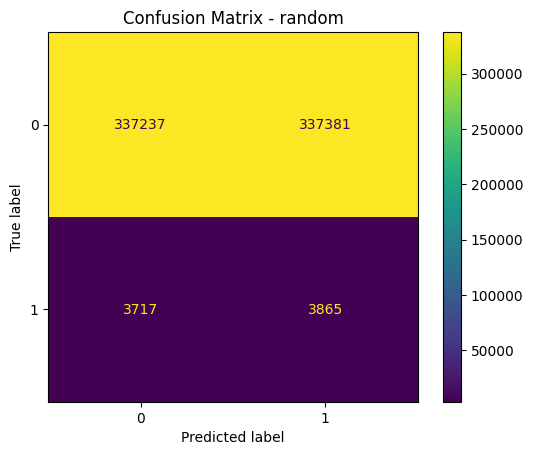

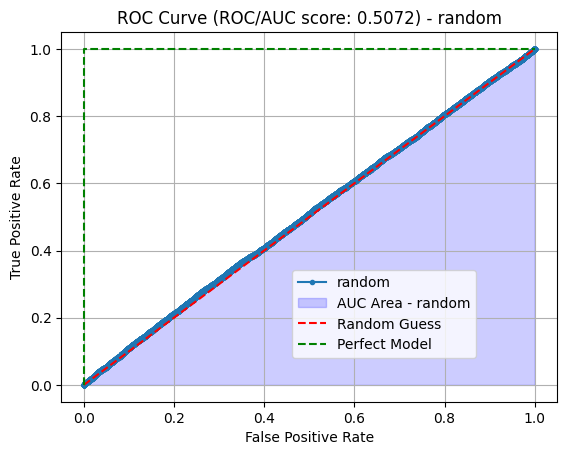

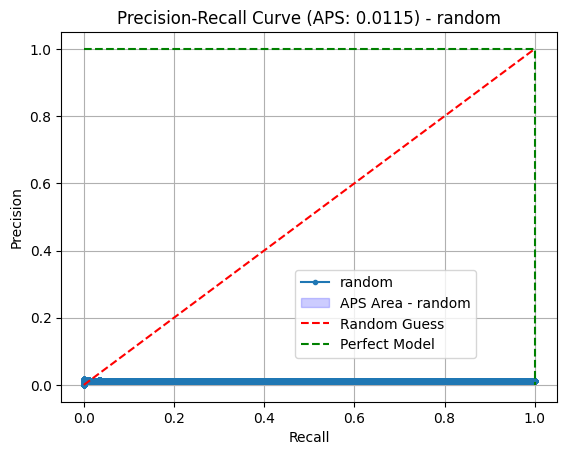

              precision    recall  f1-score   support

           0       0.99      0.50      0.66    674618
           1       0.01      0.51      0.02      7582

    accuracy                           0.50    682200
   macro avg       0.50      0.50      0.34    682200
weighted avg       0.98      0.50      0.66    682200

Average test loss on test set: 18.0217 - random


In [14]:
#baseline models:

y_n0 = np.zeros_like(y_test) #baseline model that predicts all transactions as non-fraudulent
y_n1 = np.ones_like(y_test) #baseline model that predicts all transactions as fraudulent
y_r_proba = np.random.rand(y_test.shape[0])  # random probability of class 1
y_r = (y_r_proba >= 0.5).astype(int)

#N0
ConfusionMatrixDisplay.from_predictions(y_test, y_n0)
plt.title('Confusion Matrix - n0')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y_n0)
plt.plot(fpr, tpr, marker='.', label='n0')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - n0')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y_n0):.4f}) - n0')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_n0)
plt.plot(recall[:-1], precision[:-1], marker='.', label='n0') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - n0')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
#plot ideal precision/recall curve for a perfect model, which is a step function that goes from (0,1) to (1,0)
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y_n0):.4f}) - n0')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_n0))
print(f'Average test loss on test set: {log_loss(y_test,y_n0):.4f} - n0')


#N1
ConfusionMatrixDisplay.from_predictions(y_test, y_n1)
plt.title('Confusion Matrix - n1')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y_n1)
plt.plot(fpr, tpr, marker='.', label='n1')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - n1')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y_n1):.4f}) - n1')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_n1)
plt.plot(recall[:-1], precision[:-1], marker='.', label='n1') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - n1')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y_n1):.4f}) - n1')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_n1))
print(f'Average test loss on test set: {log_loss(y_test, y_n1):.4f} - n1')

#random
ConfusionMatrixDisplay.from_predictions(y_test, y_r)
plt.title('Confusion Matrix - random')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y_r_proba)
plt.plot(fpr, tpr, marker='.', label='random')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - random')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y_r_proba):.4f}) - random')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_r_proba)
plt.plot(recall[:-1], precision[:-1], marker='.', label='random') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - random')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y_r_proba):.4f}) - random')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_r))
print(f'Average test loss on test set: {log_loss(y_test, y_r):.4f} - random')


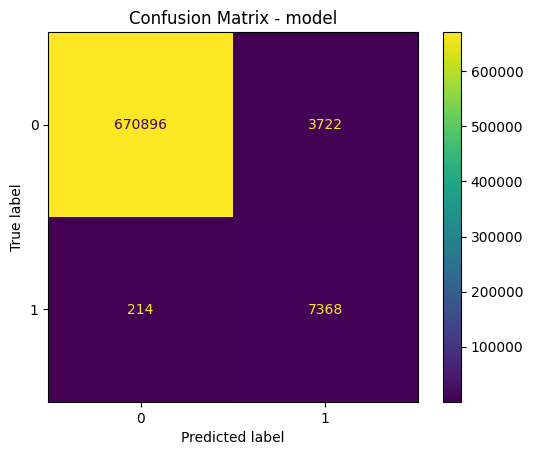

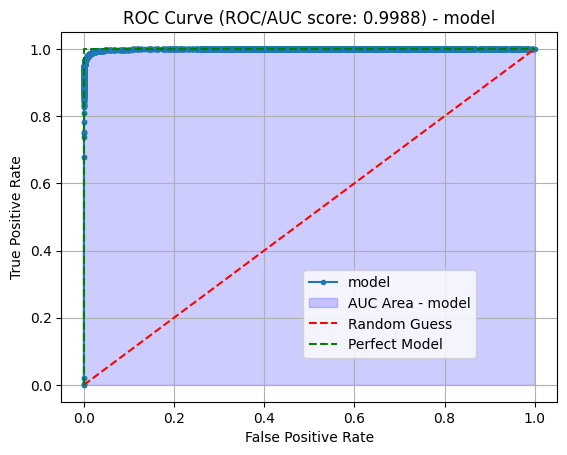

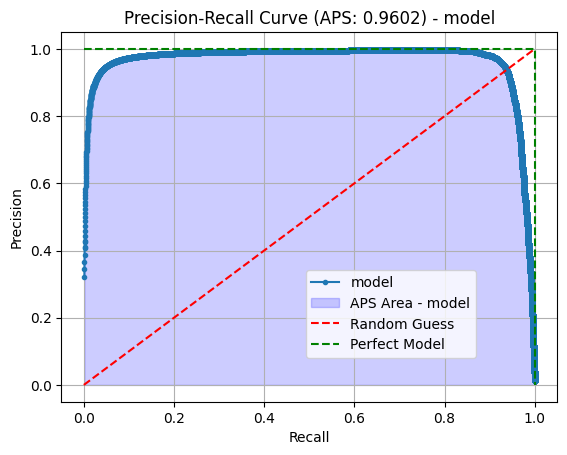

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    674618
           1       0.66      0.97      0.79      7582

    accuracy                           0.99    682200
   macro avg       0.83      0.98      0.89    682200
weighted avg       1.00      0.99      0.99    682200

Average test loss on test set: 0.0165 - model


In [15]:
y_TEST_pred = model.predict(X_test)
y__TEST_pred_proba = model.predict_proba(X_test)[:, 1] #probability of the positive class

ConfusionMatrixDisplay.from_predictions(y_test, y_TEST_pred)
plt.title('Confusion Matrix - model')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y__TEST_pred_proba)
plt.plot(fpr, tpr, marker='.', label='model')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y__TEST_pred_proba):.4f}) - model')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y__TEST_pred_proba)
plt.plot(recall[:-1], precision[:-1], marker='.', label='model') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y__TEST_pred_proba):.4f}) - model')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_TEST_pred))
print(f'Average test loss on test set: {log_loss(y_test, y__TEST_pred_proba):.4f} - model')


## Results interpretation
Let's start by looking at the baselines:

n0 and n1 behave as expected: ROC curve perfectly overlapped to the random guess. Precision/Recall curve collapsed in a single point (~0.011, the positive rate.) random shows the same behaviour, with the APS being an actual curve, albeit with a terrible score, again close to the fraud rate.

The model itself performs exceptionally well: the ROC/AUC score (0.9988) and the APS score (0.9602) are both very close to ideal (1) on the test set, showing very good generalization capability by our model.

The precision is ~1 on the negative class, 0.67 on the positive class: every three "positive" one of them is a FP. In this context, false negatives are way worse (fraud accepted, money lost, compared to a small amount of money used to check the transaction). 3722 FN vs 214 FP at 0.5 threshold is good, considering the dataset size.

The PR curve on the model has a very nice plateu, which could give us margin to tune the threshold.

# Model explainability

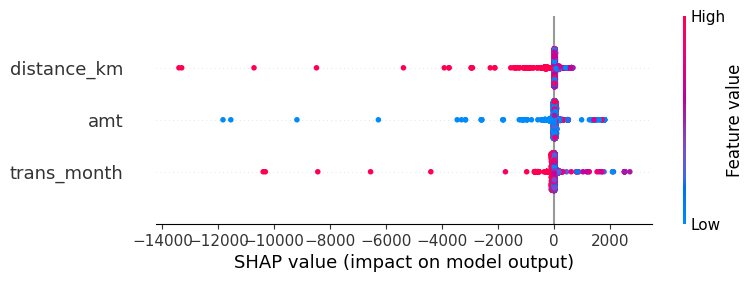

<Figure size 640x480 with 0 Axes>

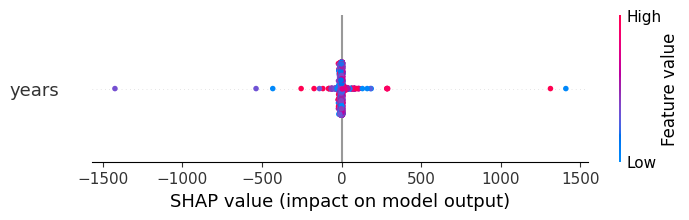

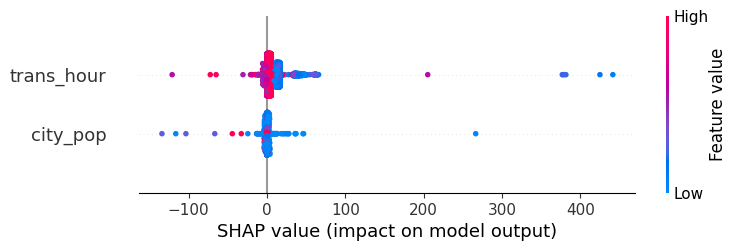

TypeError: beeswarm() got an unexpected keyword argument 'binning'

In [ ]:
#TODO SHAP EXPLAINABILITY ANALYSIS
'''
subsample x_test to 1000-5000 samples to speed up analisys.
'''

# Passo 1: prendi solo le righe dove y_test == 0
X_test_legit = X_test[ y_test==0 ]

# Passo 2: prendi solo le righe dove y_test == 1  
X_test_fraud = X_test[ y_test==1 ]

# Passo 3: campiona N righe da ciascuno e uniscili
X_SHAP_sample = pd.concat([
    X_test_legit.sample(5000, random_state=GLOBAL_SEED),
    X_test_fraud.sample(5000, random_state=GLOBAL_SEED)
])
#TODO combine them in oneliner


#---EXPLAINER---
explainer = shap.TreeExplainer(model)

#beeswarm plot
shap_values = explainer(X_SHAP_sample)
plt.figure()
shap.plots.beeswarm(shap_values[:, ['distance_km', 'amt', 'trans_month']])
#shap.plots.beeswarm(shap_values)
plt.tight_layout()

plt.figure()

shap.plots.beeswarm(shap_values[:, ['years']])

shap.plots.beeswarm(shap_values[:, ['trans_hour', 'city_pop']])

shap.plots.beeswarm(shap_values[:, ['category', 'gender', 'profile']])

In [17]:
'''
import shap

# Feature importance — quali feature sono più utili per predire le frodi?
import pandas as pd

feature_names = X_train.columns.tolist()
importances = model.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.title('LightGBM - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# TreeExplainer è ottimizzato per modelli ad albero come LightGBM
explainer = shap.TreeExplainer(model)

# Calcoliamo i SHAP values su un campione della val set (è computazionalmente costoso)
X_val_sample = X_val.sample(n=20000, random_state=GLOBAL_SEED)
shap_values = explainer.shap_values(X_val_sample)
# shap_values è una lista [classe_0, classe_1] — usiamo classe_1 (frode)

# --- Summary Plot ---
# Ogni punto è un'osservazione. Colore = valore della feature, asse x = impatto sulla predizione.
# Feature in cima = più importanti. Rosso a destra = alta feature → più probabilità di frode.
print('Summary Plot (global feature importance + direzione):')
shap.summary_plot(shap_values, X_val_sample)

# --- Bar Plot ---
# Versione semplificata: importanza media assoluta per feature
print('Bar Plot (mean absolute SHAP value):')
shap.summary_plot(shap_values, X_val_sample, plot_type='bar')

# --- Force Plot su una singola predizione ---
# Spiega perché il modello ha dato un certo score a UNA transazione specifica.
# Scegli un'indice con alta probabilità di frode per un esempio interessante
sample_proba = model.predict_proba(X_val_sample)[:, 1]
high_fraud_idx = sample_proba.argmax()  # la transazione con score di frode più alto

print(f'Force Plot per la transazione con score frode più alto (score: {sample_proba[high_fraud_idx]:.4f}):')
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[high_fraud_idx],
    X_val_sample.iloc[high_fraud_idx],
    matplotlib=True  # usa matplotlib invece di JS per compatibilità notebook
)
'''

"\nimport shap\n\n# Feature importance — quali feature sono più utili per predire le frodi?\nimport pandas as pd\n\nfeature_names = X_train.columns.tolist()\nimportances = model.feature_importances_\n\nfi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})\nfi_df = fi_df.sort_values('importance', ascending=True)\n\nplt.figure(figsize=(10, 8))\nplt.barh(fi_df['feature'], fi_df['importance'])\nplt.title('LightGBM - Feature Importance')\nplt.xlabel('Importance')\nplt.tight_layout()\nplt.show()\n\n# TreeExplainer è ottimizzato per modelli ad albero come LightGBM\nexplainer = shap.TreeExplainer(model)\n\n# Calcoliamo i SHAP values su un campione della val set (è computazionalmente costoso)\nX_val_sample = X_val.sample(n=20000, random_state=GLOBAL_SEED)\nshap_values = explainer.shap_values(X_val_sample)\n# shap_values è una lista [classe_0, classe_1] — usiamo classe_1 (frode)\n\n# --- Summary Plot ---\n# Ogni punto è un'osservazione. Colore = valore della feature, asse x

# Bandits time!
In this section we tackle the cost problem, bank side! Sure, the algo we just tested can predict if a transaction is likely to be a fraud, but we can't afford to investigate all the positives! The problem to solve is: given a transaction with features x and with P(x=Fraud) = p, is it worth it for the bank to pursue the investigation?

In [18]:
y_train

1187828    0
3185422    0
2115263    0
1949401    0
1608451    0
          ..
97941      0
2959547    0
228832     0
1922951    0
2179805    0
Name: is_fraud, Length: 2592358, dtype: int64

## Bandits preprocessing
For the bandit section, we have some choices to make. First of all, how many features should be included in our context?

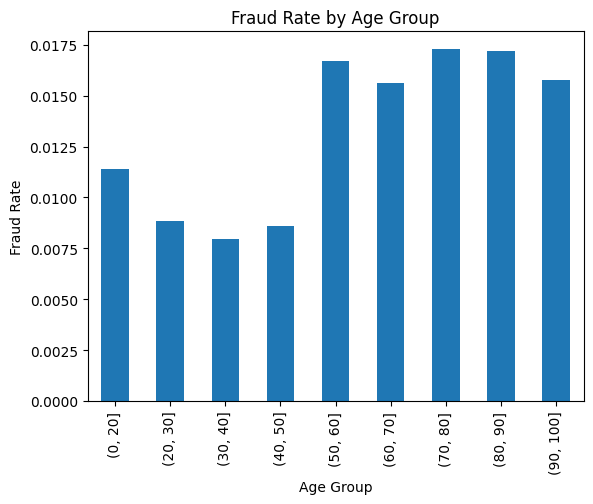

In [19]:
#count how many transaction labeled isfrauds 1 were M and F in the train set.
X_train[y_train == 1]['gender'].value_counts()
X_train[y_train == 0]['profile'].value_counts() #todo calcola percentuali per ogni categoria, non solo count, altrimenti è difficile capire se una categoria è più fraudolenta di un'altra o se semplicemente è più rappresentata nel dataset.


# fraud rate per age group
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_group = pd.cut(X_train['years'], bins=age_bins)

# y_train contains the labels, so aggregate y_train by the age groups
age_group_fraud_rate = y_train.groupby(age_group, observed=False).mean()

age_group_fraud_rate.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Age Group')
plt.show()


In [20]:
#TODO
"""
prendi X_test #TODO motiva bene data leakage su p
calcola p_fraud eseguendo model.predict.proba
appendi p_fraud a X_test
dividi in X_sim e X_prod con scikit
applica il preprocessor
applica il bandi_preprocessor (merge dei due?)
"""

def bandits_preprocessing(X):
    #category one-hot encoding
    X = pd.get_dummies(X, columns=['category'], dtype=int)
    X['gender'] = X['gender'].map({'F': 0, 'M': 1})
    X['profile'] = X['profile'].map({'rural': 0, 'urban': 1})    
    return X



In [21]:
X_b = X_test.copy() #TODO remove X_test from memory - efficiency (decomment line below)
#del X_test 


#---get predictions from SL model
#LightGBM_actions = model.predict(X_b)+1 #get actions from LightGBM model, these will be used as a baseline for the bandit model, TODO - maybe we can use the predicted probabilities instead of the binary predictions, to give more information to the bandit model? da testare
X_b['p_fraud'] = model.predict_proba(X_b)[:,1] #add p_fraud to dataset before preprocessing using the LightGBM model trained above

#preprocessing for bandits
X_bf = bandits_preprocessing(X_b) #TODO sostituire X_bf con X_b dopo il testing
#print(X_bf.head()) #check if preprocessing is correct, se tutto ok sostituisci X_bf con X_b e rimuovi questa print


Reward lookup table, for clean code (way better and scalable than elif chain)

|     _REWARDS_    | **Transaction: legit [0]** | **Transaction: fraud [1]** |
|:--------------------:|----------------|----------------|
| **Action: ACCEPT [0]**  | +0        | -amount        |
| **Action: BLOCK [1]** | -labour cost          | +amount-labour cost          |

Accepting a legit transaction has no cost at all.

Accepting a fraudolent transaction makes so the bank loses money

Blocking a legit one makes you lose the analyst's wage

Blocking a fraudolent one makes you lose the analyst's wage, but you gain back the transaction amount that would otherwise be lost.

In [22]:
X_test

,gender,city_pop,years,profile,trans_month,trans_hour,category,amt,distance_km
1959594,F,44654,89,urban,3,7,grocery_pos,84.79,51.796183
2403632,F,1595797,94,urban,1,0,grocery_pos,308.32,110.119027
2779669,M,73614,77,urban,1,2,gas_transport,21.86,85.569748
1859517,M,9548,41,urban,11,15,home,1.91,77.796901
417270,F,1417793,35,urban,8,23,entertainment,60.64,111.175358
...,...,...,...,...,...,...,...,...,...
1769276,M,1417793,36,urban,5,7,misc_net,87.12,43.670407
1096708,M,167094,41,urban,4,8,grocery_pos,46.91,120.736232
1989855,F,29837,92,urban,12,22,kids_pets,35.45,78.890935
2470038,F,769341,56,urban,10,20,home,32.36,102.739076


In [23]:
y_test

1959594    0
2403632    1
2779669    0
1859517    0
417270     0
          ..
1769276    0
1096708    0
1989855    0
2470038    0
2472200    0
Name: is_fraud, Length: 682200, dtype: int64

In [24]:
#DEBUG - this exists only to check the output of the context
#print(build_context(X_test.iloc[0]))

In [25]:
'''
#Reward table lookup:
def get_reward(context, truth, action):
    action = action - 1 #convert action to 0-indexed for table lookup
    labour_cost = 32.5
    amount = context['amt']
    risk = context['p_fraud'] * context['amt'] #risk is the expected loss from not investigating, calculated as probability of fraud * amount
    table = np.array([
        [-risk,             -amount],
        [-risk-labour_cost,  amount-labour_cost]])
    #print('[0,0]', table[0,0], '[0,1]', table[0,1], '[1,0]', table[1,0], '[1,1]', table[1,1]) #print reward table for debugging
    return table[action, truth]

'''
#ORIGINAL Reward table lookup:
def get_reward(context, truth, action):
    action = action - 1 #convert action to 0-indexed for table lookup
    labour_cost = 32.5
    amount = context['amt']
    table = np.array([
        [0,             -amount],
        [-labour_cost,  amount-labour_cost]]) #todo rimetti amount-labour_cost
    #print('[0,0]', table[0,0], '[0,1]', table[0,1], '[1,0]', table[1,0], '[1,1]', table[1,1]) #print reward table for debugging
    return table[action, truth]


'''
def get_reward(context, truth, action): #FIXER 1
    action = action - 1
    labour_cost = 32.5
    amount = context['amt']
    fraud_weight = 20  # ~1/fraud_rate per bilanciare le classi
    table = np.array([
        [0,                         -amount * fraud_weight],
        [-labour_cost,  amount - labour_cost]])
    return table[action, truth]
'''


def build_context(row):
    # tutte le colonne tranne p_fraud sono già numeriche
    feature_cols = [col for col in row.index if col != 'p_fraud']
    feature_cols = ['gender','city_pop','years','profile','trans_month','trans_hour','amt','distance_km']
    
    #feature_cols = ['amt']
    #feature_cols = ''
    num_fs = " ".join(f"{f}:{row[f]}" for f in feature_cols)
    context = f"| p_fraud:{row['p_fraud']} {num_fs}"
    #context = f"| {num_fs}"
    #context = f"| ev:{row['p_fraud'] * row['amt']:.4f}"
    #return f"| p_fraud:{row['p_fraud']} {num_fs}"
    return context



def learning_info(action, reward, prob, context):
    return f"{action}:{reward}:{prob} {context}"




def choose_action(learner, context):
    probs = learner.predict(context) #learner outputs probability for each action
    
    probs = np.array(probs) #ensure it's a numpy array for the next operation
    probs = probs / probs.sum()  # renormalize - FIX NUMERICAL ERRORS
    
    action = np.random.choice(len(probs), p=probs) + 1  # 1-indexed choice for action
    #action = np.random.choice(len(probs), p=probs)  # 0 indexed choice for action (REMEMBER TO PUT IT 1-INDEXED FOR LEARNER)
    prob = probs[action-1] #misticanza, output della probabilità con cui è stata scelta action
    return prob, action


'''
#ORIGINAL ORACLE POLICY - only works with original reward function
def oracle_action(row, truth, c):
    v = row['amt']
    if truth == 0:
        return 1  # non indagare, reward = 0 > -c
    else:  # truth == 1
        return 2 if v > c/2 else 1  # indaga solo se vale la pena: v-c > -v -> v > c/2
'''

def oracle_action(row, truth, labour_cost):
    #return best action
    return max([(0,1), (1,2)], key=lambda x: get_reward(row, truth, x[1]))[1] #calcola reward per entrambe le azioni e restituisce quella con reward più alto

def lightgbm_action(row, threshold):
    return 2 if row['p_fraud'] > threshold else 1


from vowpalwabbit import pyvw

#parameters
EPSILON = 0.1
labour_cost = 32.5 #TODO parametrizza, ora è inutile


#build a learner with 2 actions
learner = pyvw.Workspace("--cb_explore 2 --epsilon 0.1 --cb_type dr", quiet=True)
#learner = pyvw.Workspace("--cb_explore 2 --cover 6 --cb_type dr", quiet=True) #TODO optimize cover parameter?



rewards = []
regrets = []

oracle_rewards = []
LightGBM_rewards = []

naive_never_rewards = []
naive_always_rewards = []

#warmup
"""
N_WARMUP = 10000 #FIXER 2
for i in range(N_WARMUP):
    row = X_bf.iloc[i]
    context = build_context(row)
    truth = y_test.iloc[i]
    action = np.random.choice([1, 2])  # policy uniforme
    prob = 0.5
    reward = get_reward(row, truth, action)
    learner.learn(learning_info(action, -reward, prob, context))
"""

#mask: keep in X_bf only the rows where p_fraud is > 0.05

'''
mask = X_bf['p_fraud'] > 0.4
X_bf = X_bf[mask].reset_index(drop=True)
y_test = y_test[mask].reset_index(drop=True)
'''

#LEARNING LOOP
for i in range(X_bf.shape[0]):
#for i in range(100):


    #-----LEARNER-----
    
    #build context
    row = X_bf.iloc[i]
    context = build_context(row)
    #print(context) #DEBUG - check context format, if ok remove this print
    
    #choose action in correct format
    prob, action = choose_action(learner,context) #NB: this action is 1-indexed
    #action = learner.predict(context)
    #print(action)
    truth = y_test.iloc[i]
    
    #calculate reward
    reward = get_reward(row, truth, action) #get reward for the chosen action (1-indexed, internal conversion)
    rewards.append(reward)
    #print(reward)
    
    
    #DEBUG PRINT FIX
    if action == 2 and reward > -labour_cost: #if the learner decided to investigate and it was a good decision (reward > -labour_cost) then print the context and the action distribution to check if the learner is learning to investigate the right cases
        #print actions distribution every 100 iterations to check if the learner is exploring or exploiting
        probs = learner.predict(context)
        print(f"i={i}, probs={probs}, last_action={action}, last_reward={reward}")
    #END DEBUG
    
    
    learner.learn(learning_info(action,-reward,prob,context)) #LEARNER WANTS COSTS - NOT REWARDS! lower is better
    
    #-----ORACLE-----
    oracle_rewards.append(get_reward(row,truth,oracle_action(row, truth, labour_cost))) #get reward for oracle action
    
    #----LIGHTGBM-----
    #LightGBM_rewards.append(get_reward(row,truth,LightGBM_actions[i]))
    LightGBM_rewards.append(get_reward(row,truth,lightgbm_action(row, 0.5))) 
    
    #-----NAIVE BASELINES-----
    naive_never_rewards.append(get_reward(row, truth, 1))   # action=1: non investigare mai
    naive_always_rewards.append(get_reward(row, truth, 2))  # action=2: investiga sempre
    
    
learner.finish()




c:\Users\Leo\miniconda3\envs\vw_env\lib\site-packages\vowpalwabbit\version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


i=231, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=-10.11
i=12652, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=251.02999999999997
i=12888, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=-21.119999999999997
i=16862, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=773.44
i=19085, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=836.45
i=19605, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=475.31
i=23182, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=249.13
i=23622, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=867.22
i=25532, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=848.5
i=26542, probs=[0.949999988079071, 0.05000000074505806], last_action=2, last_reward=207.78
i=29224, probs=[0.949999988079071, 0.05000000074505806], last_action

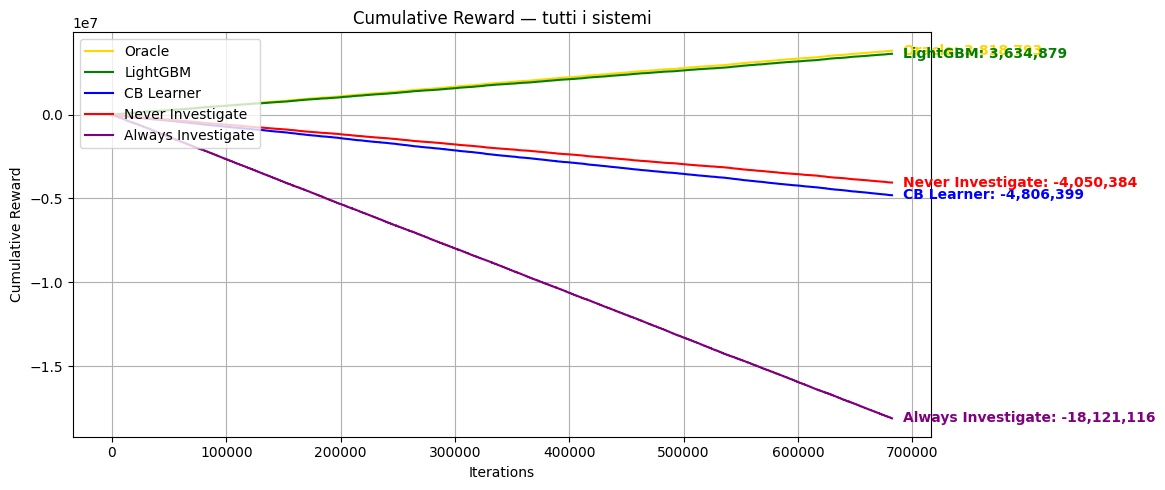

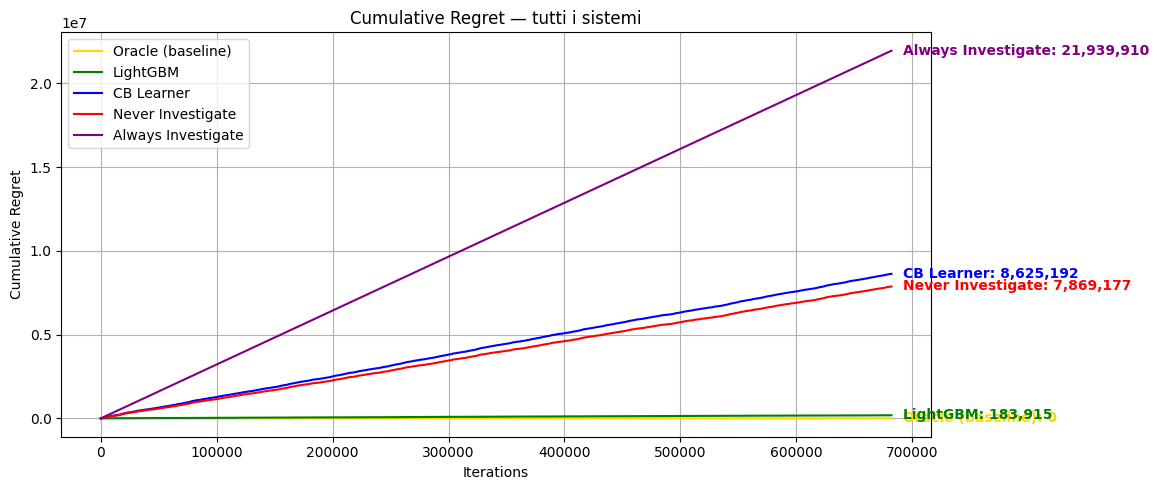

In [26]:
# --- Cumsum ---
cum_learner = np.cumsum(rewards)
cum_oracle  = np.cumsum(oracle_rewards)
cum_lgbm    = np.cumsum(LightGBM_rewards)
cum_never   = np.cumsum(naive_never_rewards)
cum_always  = np.cumsum(naive_always_rewards)

lines = [
    (cum_oracle,  'Oracle',           'gold'),
    (cum_lgbm,    'LightGBM',         'green'),
    (cum_learner, 'CB Learner',       'blue'),
    (cum_never,   'Never Investigate','red'),
    (cum_always,  'Always Investigate','purple'),
]

# --- REWARD PLOT ---
fig, ax = plt.subplots(figsize=(12, 5))
for cum, label, color in lines:
    ax.plot(range(len(cum)), cum, label=label, color=color)
    ax.annotate(
        f"{label}: {cum[-1]:,.0f}",
        xy=(len(cum)-1, cum[-1]),
        xytext=(8, 0),
        textcoords='offset points',
        color=color,
        va='center',
        fontweight='bold'
    )
ax.set_xlabel('Iterations')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward — tutti i sistemi')
ax.legend(loc='upper left')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

# --- REGRET PLOT ---
fig, ax = plt.subplots(figsize=(12, 5))
regret_lines = [
    (cum_oracle  - cum_oracle,  'Oracle (baseline)', 'gold'),
    (cum_oracle  - cum_lgbm,    'LightGBM',          'green'),
    (cum_oracle  - cum_learner, 'CB Learner',        'blue'),
    (cum_oracle  - cum_never,   'Never Investigate', 'red'),
    (cum_oracle  - cum_always,  'Always Investigate','purple'),
]
for reg, label, color in regret_lines:
    ax.plot(range(len(reg)), reg, label=label, color=color)
    ax.annotate(
        f"{label}: {reg[-1]:,.0f}",
        xy=(len(reg)-1, reg[-1]),
        xytext=(8, 0),
        textcoords='offset points',
        color=color,
        va='center',
        fontweight='bold'
    )
ax.set_xlabel('Iterations')
ax.set_ylabel('Cumulative Regret')
ax.set_title('Cumulative Regret — tutti i sistemi')
ax.legend(loc='upper left')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()
